# 06 Cross-domain design recommendations

This notebook combines outputs from the real-data domain notebooks and the appendix diagnostics. The paper-facing summary is restricted to the three representative real-data cases, Criteo, Open Bandit, and KuaiRand. Synthetic selector diagnostics and MovieLens graph simulations remain available as appendix checks.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "online_experiment_designs_under_interference" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "code" / "src"))

from config import ProjectPaths
from designs import pareto_frontier, uncertainty_shortlist
from figures import plot_case_recommendations
from progress import ProgressLogger
from tables import write_table

paths = ProjectPaths.from_anywhere(PROJECT_ROOT)
paths.ensure()
progress = ProgressLogger("06-cross-domain")

In [2]:
progress.log("Loading design-score tables produced by notebooks 01 through 05.")
score_files = {
    "01_synthetic_scenario_design_scores.csv": "appendix_synthetic",
    "02_criteo_ads_design_scores.csv": "main_body_real_data",
    "03_open_bandit_design_scores.csv": "main_body_real_data",
    "04_kuairand_design_scores.csv": "main_body_real_data",
    "05_movielens_graph_design_scores.csv": "appendix_graph_simulation",
}
frames = []
for name, placement in score_files.items():
    path = paths.table_dir / name
    if not path.exists():
        raise FileNotFoundError(f"Run the upstream notebook before this one: {path}")
    frame = pd.read_csv(path)
    frame["paper_placement"] = placement

    if name == "03_open_bandit_design_scores.csv":
        if "open_bandit_slice" not in frame.columns:
            raise ValueError("Notebook 03 must be rerun so Open Bandit slice labels are available.")
        is_bts = frame["open_bandit_slice"] == "bts/men"
        is_random = frame["open_bandit_slice"] == "random/men"
        frame.loc[is_bts, "case"] = "open_bandit_bts_known_propensity"
        frame.loc[is_random, "case"] = "open_bandit_random_uniform_baseline"
        frame.loc[is_random, "paper_placement"] = "appendix_known_propensity_baseline"
        frame["main_body_representative"] = is_bts
    else:
        frame["main_body_representative"] = placement == "main_body_real_data"

    frames.append(frame)
all_scores = pd.concat(frames, ignore_index=True)
main_scores = all_scores[all_scores["main_body_representative"]].copy()
write_table(all_scores, paths.table_dir / "06_all_design_scores.csv")
write_table(main_scores, paths.table_dir / "06_main_body_real_data_design_scores.csv")
main_scores.head()


[04:28:09] 06-cross-domain: Loading design-score tables produced by notebooks 01 through 05.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/06_all_design_scores.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/06_main_body_real_data_design_scores.csv


,design,mean_estimate,sd,mean_mde,assignment_units,exposure_distance,assignment_unit_variance,planning_mde,spillover_contamination,carryover_contamination,...,calibration_max_propensity,behavior_policy,campaign,open_bandit_slice,calibration_outcome_col,calibration_outcome_mean,calibration_n_users,calibration_n_items,calibration_has_time,calibration_rating_sd
24,user_randomization,0.010192,0.001610,0.005539,3000.0,0.515833,0.005870,0.005539,0.247392,0.034726,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,switchback,0.016718,0.005474,0.008875,14.0,0.793397,0.000073,0.008875,0.000000,0.223833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,budget_split,0.020007,0.020557,0.024902,30.0,0.586741,0.001189,0.024902,0.000000,0.474131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,cluster_randomization,0.032801,0.016396,0.056841,60.0,0.926262,0.012366,0.056841,0.064044,0.131250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,mixed_randomization,0.017772,0.008395,0.040156,765.0,0.590185,0.078692,0.040156,0.000000,0.384488,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
progress.log("Selecting the lowest-risk design within each main-body real-data scenario.")
paper_columns = [
    "case",
    "design",
    "design_risk",
    "mean_estimate",
    "true_launch_effect",
    "bias",
    "exposure_distance",
    "assignment_unit_variance",
    "planning_mde",
    "contamination_risk",
    "assignment_units",
    "paper_placement",
]
robust_columns = [
    "worst_case_theta_id",
    "worst_case_mechanism_label",
    "worst_case_gamma_g",
    "worst_case_gamma_b",
    "worst_case_lambda",
    "worst_case_locality",
    "n_mechanisms",
    "robust_selection_rule",
]
available_columns = [col for col in paper_columns + robust_columns if col in main_scores.columns]
recommendations = main_scores.sort_values(["case", "design_risk"]).groupby("case", as_index=False).first()
recommendations = recommendations[available_columns]
write_table(recommendations, paths.table_dir / "06_design_recommendations.csv")

appendix_available_columns = [col for col in paper_columns + robust_columns if col in all_scores.columns]
appendix_recommendations = all_scores.sort_values(["case", "design_risk"]).groupby("case", as_index=False).first()
appendix_recommendations = appendix_recommendations[appendix_available_columns]
write_table(appendix_recommendations, paths.table_dir / "06_appendix_all_case_design_recommendations.csv")

frontiers = []
shortlists = []
for case, group in main_scores.groupby("case"):
    frontier = pareto_frontier(group).copy()
    shortlist = uncertainty_shortlist(group).copy()
    frontier["case"] = case
    shortlist["case"] = case
    frontiers.append(frontier)
    shortlists.append(shortlist)
frontiers = pd.concat(frontiers, ignore_index=True)
shortlists = pd.concat(shortlists, ignore_index=True)
write_table(frontiers, paths.table_dir / "06_cross_domain_pareto_frontiers.csv")
write_table(shortlists, paths.table_dir / "06_cross_domain_uncertainty_shortlists.csv")
recommendations


[04:28:09] 06-cross-domain: Selecting the lowest-risk design within each main-body real-data scenario.
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/06_design_recommendations.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/06_appendix_all_case_design_recommendations.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/06_cross_domain_pareto_frontiers.csv
[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/tables/06_cross_domain_uncertainty_shortlists.csv


,case,design,design_risk,mean_estimate,true_launch_effect,bias,exposure_distance,assignment_unit_variance,planning_mde,contamination_risk,assignment_units,paper_placement,worst_case_theta_id,worst_case_mechanism_label,worst_case_gamma_g,worst_case_gamma_b,worst_case_lambda,worst_case_locality,n_mechanisms,robust_selection_rule
0,criteo_ads_budget_interference,user_randomization,1.294505,0.010192,0.019660,-0.009468,0.515833,0.005870,0.005539,0.247392,3000.0,main_body_real_data,criteo_ads_theta_09,g0.00_b0.20_l0.00_campaign,0.0,0.2,0.00,campaign,81.0,max_theta_design_risk
1,kuairand_member_experience_carryover,cluster_randomization,2.240215,0.047549,0.051514,-0.003965,0.540028,0.000945,0.013020,0.494721,87.0,main_body_real_data,kuairand_theta_03,g0.00_b0.00_l0.05_campaign,0.0,0.0,0.05,campaign,81.0,max_theta_design_risk
2,open_bandit_bts_known_propensity,switchback,2.105236,0.022363,0.020580,0.001783,0.714409,0.000133,0.012178,0.126384,14.0,main_body_real_data,open_bandit_theta_16,g0.00_b0.20_l0.20_advertiser,0.0,0.2,0.20,advertiser,81.0,max_theta_design_risk


[saved] /home/apex/Documents/ranking_sys/notebooks/writing/online_experiment_designs_under_interference/code/artifacts/figures/06_cross_domain_design_recommendations.png


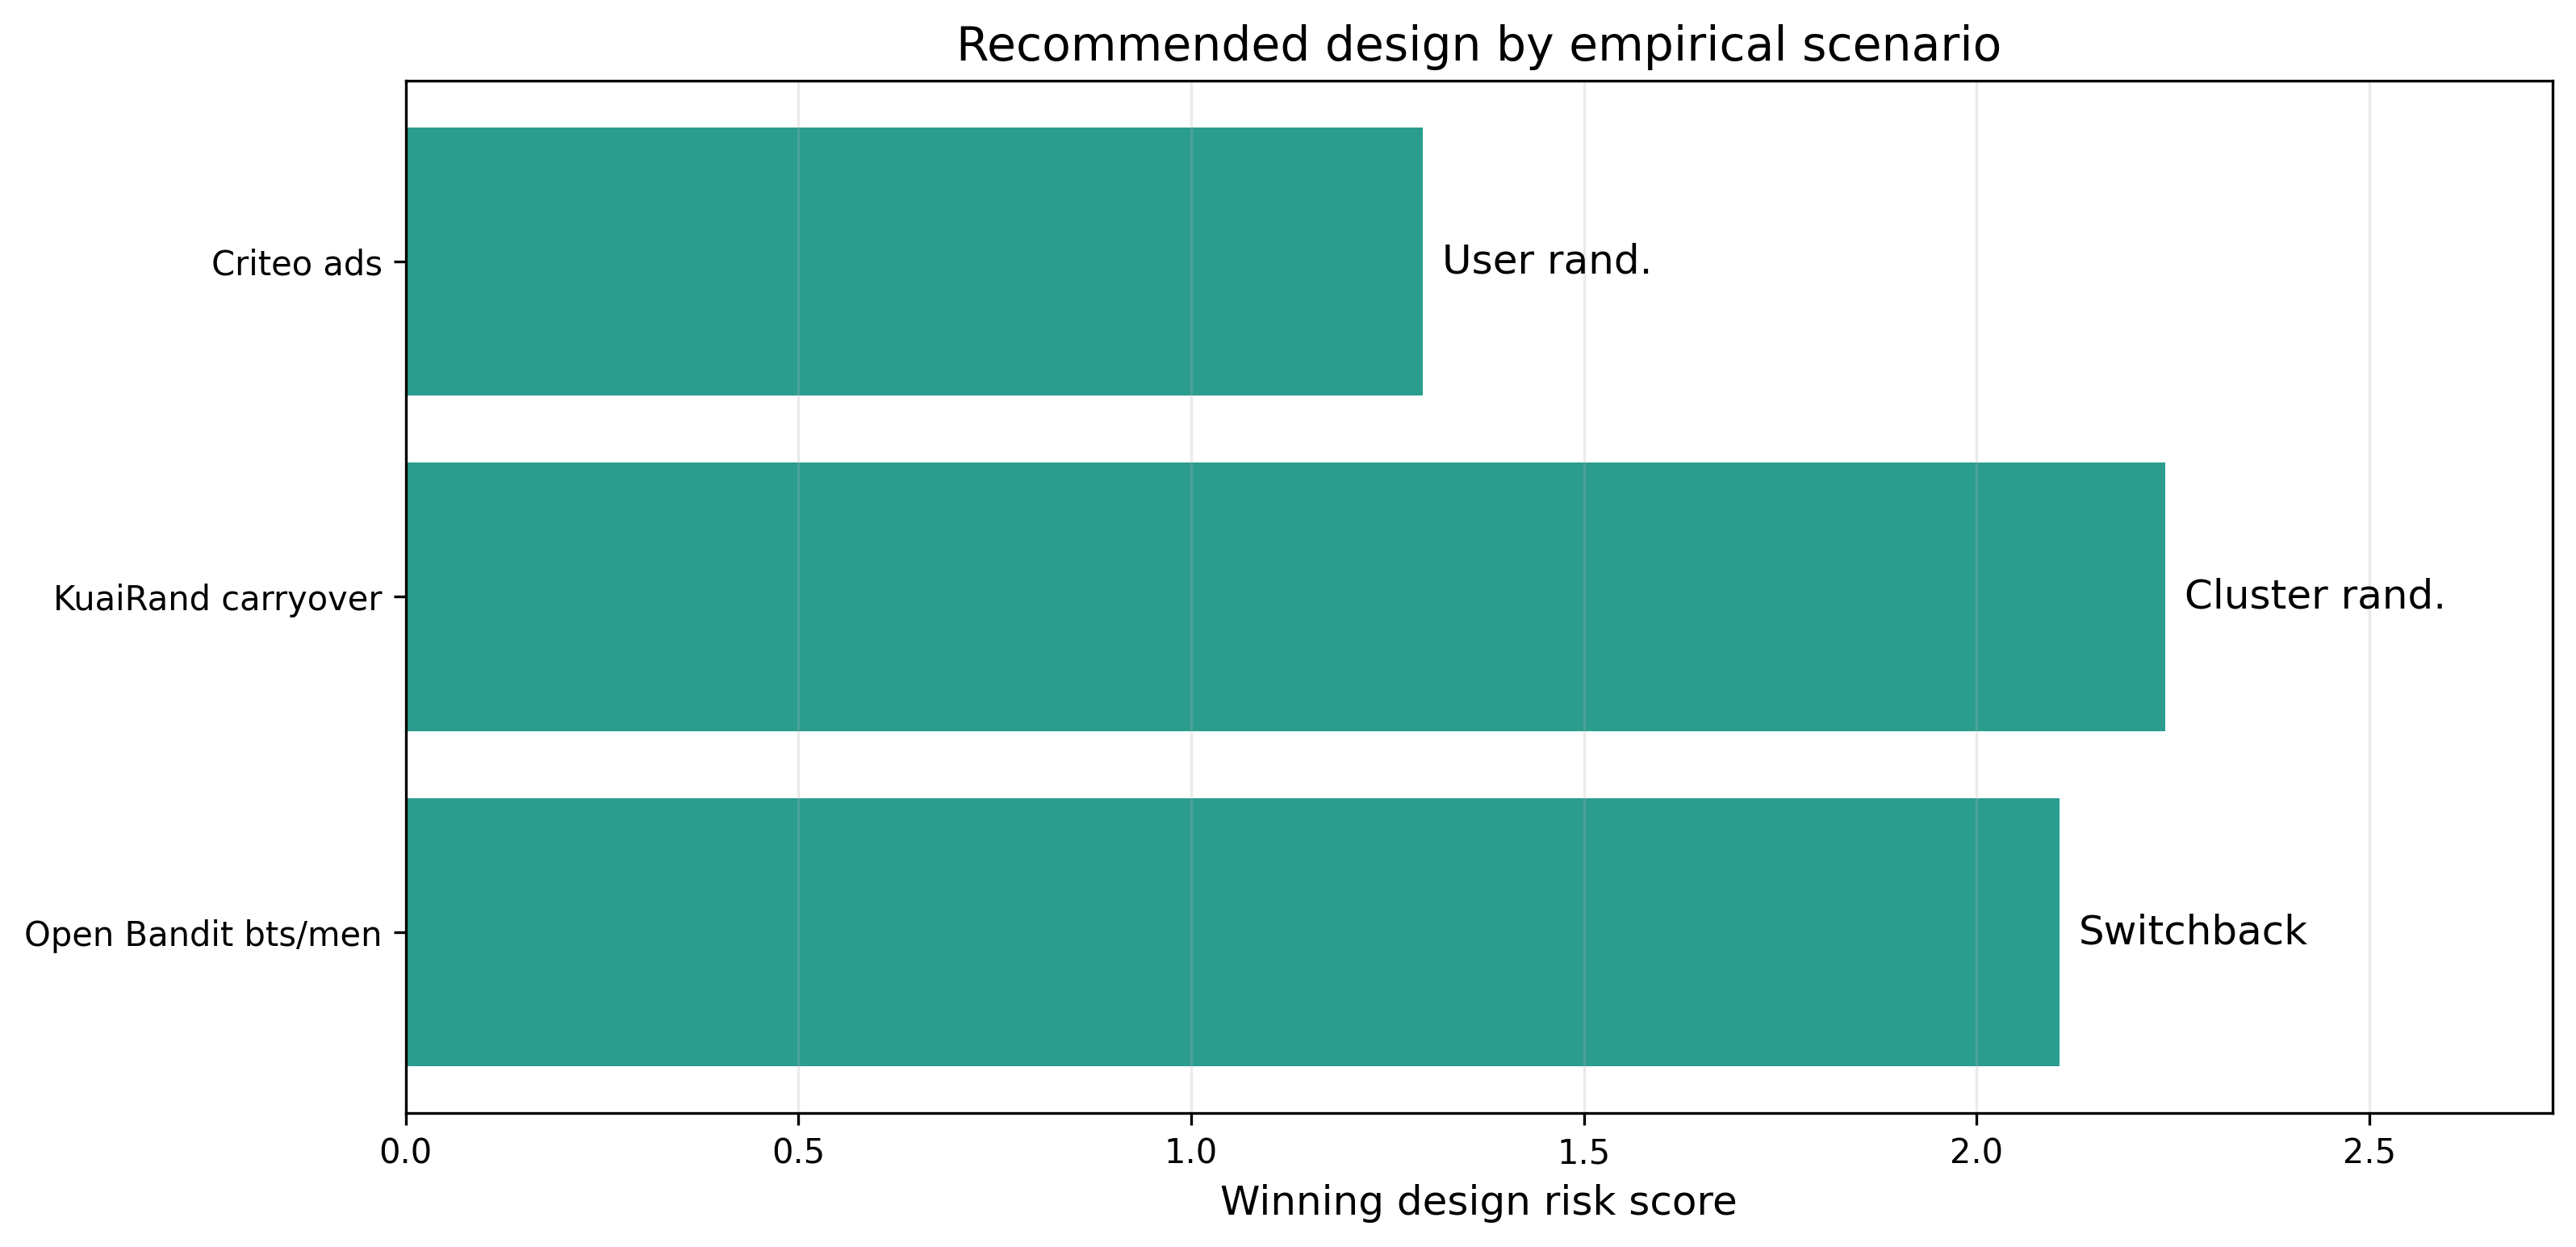

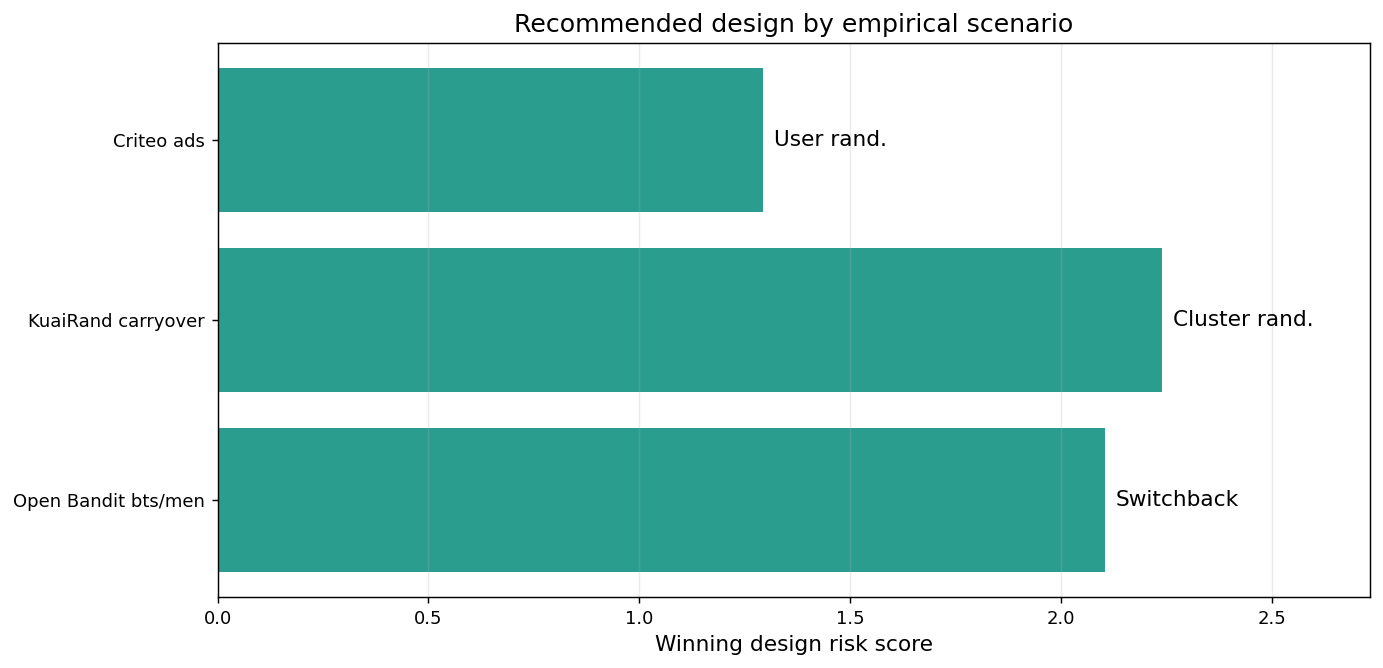

In [4]:
fig_path = paths.figure_dir / "06_cross_domain_design_recommendations.png"
plot_case_recommendations(main_scores, fig_path)
display(Image(filename=str(fig_path)))


The paper-facing interpretation should emphasize that the robust design selector is evaluated on three main real-data cases: Criteo ads incrementality, Open Bandit `bts/men` adaptive recommendation logging, and KuaiRand sequential recommendation carryover. The Open Bandit `random/men` slice is preserved as a known-propensity baseline, but the paper-facing recommendation uses `bts/men` because it is the realistic support-stress case. Synthetic selector diagnostics and MovieLens graph simulations remain useful appendix checks because they isolate theorem behavior rather than anchoring the main empirical narrative.
